In [5]:
# ============================================
# CELL 1: IMPORT LIBRARIES & EXPLORE DATA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create charts folder
os.makedirs('charts', exist_ok=True)

# Load dataset
df2 = pd.read_csv('data.csv', sep=';')

print("="*50)
print("PAGE PERFORMANCE DATASET")
print("="*50)
print(f"Shape: {df2.shape}")
print(f"\nColumns:")
for col in df2.columns:
    print(f"  - {col}")
print(f"\nFirst 5 Rows:")
print(df2.head())
print(f"\nMissing Values:")
print(df2.isnull().sum())
print(f"\nBasic Statistics:")
print(df2.describe())

PAGE PERFORMANCE DATASET
Shape: (9439, 19)

Columns:
  - Clicks
  - Impressions
  - Position
  - BounceRate
  - ViewDepth
  - TimeSpent
  - RobotsVisits
  - Mobility
  - Segments
  - Title Length
  - Meta Description Length
  - H1 Length
  - Word Count
  - Sentence Count
  - Folder Depth
  - Link Score
  - Inlinks
  - Outlinks
  - Response Time

First 5 Rows:
   Clicks  Impressions Position   BounceRate    ViewDepth TimeSpent  \
0    1939        41950      8,6  0,099963045  2,657335551  00:11:30   
1    1798        27042      8,2  0,314511575   1,15471485  00:00:41   
2     951        18076      6,3   0,33880422   1,25908558  00:00:53   
3     863        10697      7,9  0,262893983  1,348853868  00:00:43   
4     822         7269     17,8  0,221176471  3,207843137  00:02:19   

   RobotsVisits     Mobility Segments  Title Length  Meta Description Length  \
0         837.0  0,271618625      NaN          83.0                    188.0   
1           7.0  0,869000565  product         152.0

In [6]:
# ============================================
# CELL 2: CLEAN DATA
# ============================================

# Fix BounceRate
df2['BounceRate'] = df2[
    'BounceRate'].astype(str).str.replace(
    ',', '.', regex=False)
df2['BounceRate'] = pd.to_numeric(
    df2['BounceRate'], errors='coerce')

# Fix ViewDepth
df2['ViewDepth'] = df2[
    'ViewDepth'].astype(str).str.replace(
    ',', '.', regex=False)
df2['ViewDepth'] = pd.to_numeric(
    df2['ViewDepth'], errors='coerce')

# Fix Mobility
df2['Mobility'] = df2[
    'Mobility'].astype(str).str.replace(
    ',', '.', regex=False)
df2['Mobility'] = pd.to_numeric(
    df2['Mobility'], errors='coerce')

# Fix Position
df2['Position'] = df2[
    'Position'].astype(str).str.replace(
    ',', '.', regex=False)
df2['Position'] = pd.to_numeric(
    df2['Position'], errors='coerce')

# Fix Segments missing values
df2['Segments'] = df2[
    'Segments'].fillna('Other')

# Fill missing numeric values
for col in df2.select_dtypes(
           include=[np.number]).columns:
    df2[col] = df2[col].fillna(
               df2[col].mean())

# Fill missing text values
for col in df2.select_dtypes(
           include=['object']).columns:
    df2[col] = df2[col].fillna('Unknown')

# Remove duplicates
df2 = df2.drop_duplicates()

print("="*50)
print("CLEANING COMPLETE")
print("="*50)
print(f"Total Rows    : {len(df2)}")
print(f"Total Columns : {len(df2.columns)}")
print(f"\nMissing Values After Cleaning:")
print(df2.isnull().sum())
print(f"\nData Types:")
print(df2.dtypes)
print(f"\nSample After Cleaning:")
print(df2.head())

# Save cleaned data
df2.to_csv('cleaned_page_data.csv',
            index=False)
print("\n✅ Saved: cleaned_page_data.csv")

CLEANING COMPLETE
Total Rows    : 9439
Total Columns : 19

Missing Values After Cleaning:
Clicks                     0
Impressions                0
Position                   0
BounceRate                 0
ViewDepth                  0
TimeSpent                  0
RobotsVisits               0
Mobility                   0
Segments                   0
Title Length               0
Meta Description Length    0
H1 Length                  0
Word Count                 0
Sentence Count             0
Folder Depth               0
Link Score                 0
Inlinks                    0
Outlinks                   0
Response Time              0
dtype: int64

Data Types:
Clicks                       int64
Impressions                  int64
Position                   float64
BounceRate                 float64
ViewDepth                  float64
TimeSpent                      str
RobotsVisits               float64
Mobility                   float64
Segments                       str
Title Length      

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4152\3525442553.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df2.select_dtypes(


In [7]:
# ============================================
# CELL 3: PAGE SEGMENT ANALYSIS
# ============================================

print("="*50)
print("PAGE SEGMENT ANALYSIS")
print("="*50)

# Group by Segments
segment_perf = df2.groupby('Segments').agg({
    'Clicks'      : 'sum',
    'Impressions' : 'sum',
    'BounceRate'  : 'mean',
    'ViewDepth'   : 'mean',
    'Inlinks'     : 'sum',
    'Outlinks'    : 'sum'
}).round(4)

# Calculate CTR
segment_perf['CTR'] = (
    segment_perf['Clicks'] /
    segment_perf['Impressions'] * 100
).round(2)

# Sort by Clicks
segment_perf = segment_perf.sort_values(
    'Clicks', ascending=False)

print("\nALL SEGMENTS PERFORMANCE:")
print(segment_perf)

# Save
segment_perf.reset_index().to_csv(
    'powerbi_page_performance.csv',
    index=False)
print("\n✅ Saved: powerbi_page_performance.csv")

PAGE SEGMENT ANALYSIS

ALL SEGMENTS PERFORMANCE:
          Clicks  Impressions  BounceRate  ViewDepth       Inlinks  \
Segments                                                             
product    26220      1132768      0.3249     1.4541  4.948230e+05   
catalog    19306      1516421      0.3146     1.5044  1.094884e+06   
Other       9228       277095      0.3016     1.6724  3.324134e+05   
brands      1690        93850      0.3086     1.5713  2.761870e+05   

              Outlinks   CTR  
Segments                      
product   2.599320e+05  2.31  
catalog   1.022291e+06  1.27  
Other     7.508066e+04  3.33  
brands    1.059270e+05  1.80  

✅ Saved: powerbi_page_performance.csv


In [8]:
# ============================================
# CELL 4: HIGH & LOW PERFORMING PAGES
# ============================================

print("="*50)
print("HIGH & LOW PERFORMING PAGES")
print("="*50)

# High Performing - Most Clicks
print("\n🏆 TOP 5 HIGH PERFORMING PAGES:")
print("(Based on Total Clicks)")
high_clicks = segment_perf.nlargest(
              5, 'Clicks')
print(high_clicks[[
    'Clicks',
    'Impressions',
    'BounceRate',
    'CTR'
]])

# High Performing - Best CTR
print("\n🏆 TOP 5 PAGES BY CTR:")
high_ctr = segment_perf.nlargest(5, 'CTR')
print(high_ctr[[
    'Clicks',
    'Impressions',
    'CTR',
    'BounceRate'
]])

# Low Performing - High Bounce Rate
print("\n⚠️ TOP 5 LOW PERFORMING PAGES:")
print("(Based on High Bounce Rate)")
low_perf = segment_perf.nlargest(
           5, 'BounceRate')
print(low_perf[[
    'Clicks',
    'BounceRate',
    'ViewDepth',
    'CTR'
]])

# Low Performing - Least Clicks
print("\n⚠️ TOP 5 PAGES WITH LEAST CLICKS:")
least_clicks = segment_perf.nsmallest(
               5, 'Clicks')
print(least_clicks[[
    'Clicks',
    'Impressions',
    'BounceRate',
    'CTR'
]])

HIGH & LOW PERFORMING PAGES

🏆 TOP 5 HIGH PERFORMING PAGES:
(Based on Total Clicks)
          Clicks  Impressions  BounceRate   CTR
Segments                                       
product    26220      1132768      0.3249  2.31
catalog    19306      1516421      0.3146  1.27
Other       9228       277095      0.3016  3.33
brands      1690        93850      0.3086  1.80

🏆 TOP 5 PAGES BY CTR:
          Clicks  Impressions   CTR  BounceRate
Segments                                       
Other       9228       277095  3.33      0.3016
product    26220      1132768  2.31      0.3249
brands      1690        93850  1.80      0.3086
catalog    19306      1516421  1.27      0.3146

⚠️ TOP 5 LOW PERFORMING PAGES:
(Based on High Bounce Rate)
          Clicks  BounceRate  ViewDepth   CTR
Segments                                     
product    26220      0.3249     1.4541  2.31
catalog    19306      0.3146     1.5044  1.27
brands      1690      0.3086     1.5713  1.80
Other       9228      0.301

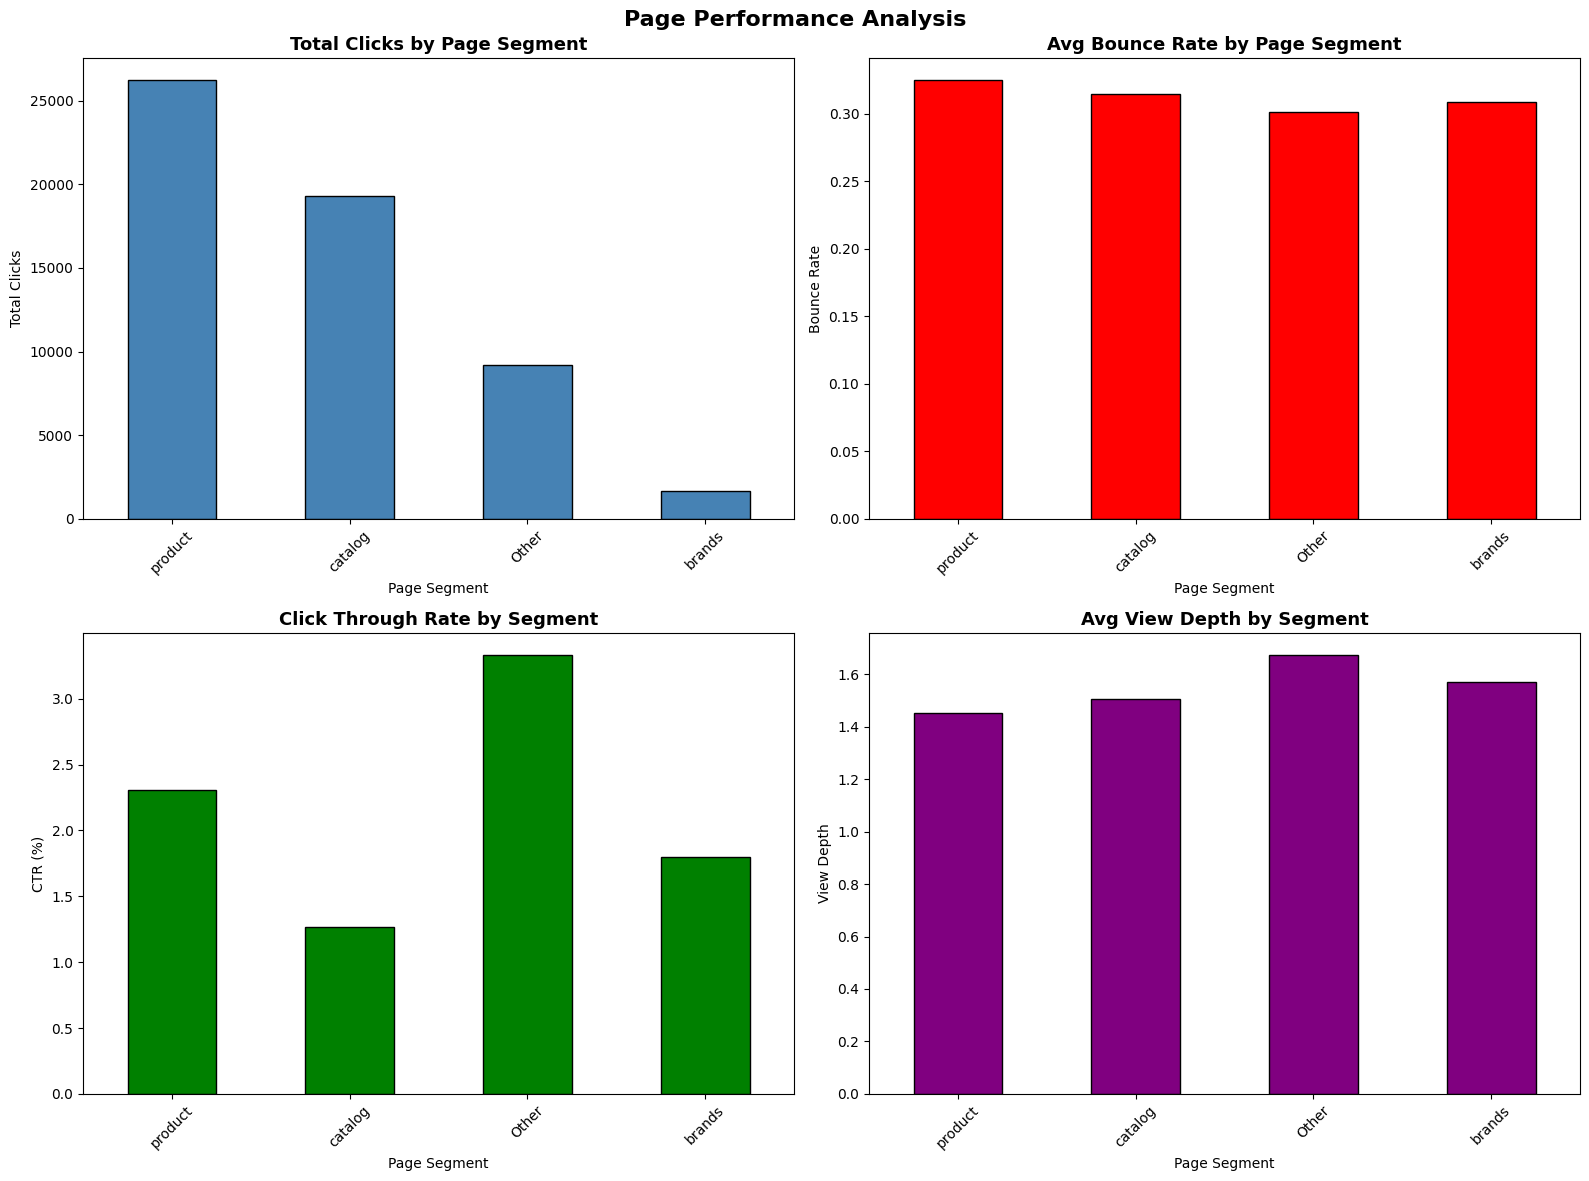

✅ Saved: chart_page_performance.png


In [9]:
# ============================================
# CELL 5: PAGE PERFORMANCE CHARTS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Clicks by Segment
segment_perf['Clicks'].plot(
    kind='bar',
    ax=axes[0, 0],
    color='steelblue',
    edgecolor='black'
)
axes[0, 0].set_title(
    'Total Clicks by Page Segment',
    fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Page Segment')
axes[0, 0].set_ylabel('Total Clicks')
axes[0, 0].tick_params(
    axis='x', rotation=45)

# Chart 2: Bounce Rate by Segment
segment_perf['BounceRate'].plot(
    kind='bar',
    ax=axes[0, 1],
    color='red',
    edgecolor='black'
)
axes[0, 1].set_title(
    'Avg Bounce Rate by Page Segment',
    fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Page Segment')
axes[0, 1].set_ylabel('Bounce Rate')
axes[0, 1].tick_params(
    axis='x', rotation=45)

# Chart 3: CTR by Segment
segment_perf['CTR'].plot(
    kind='bar',
    ax=axes[1, 0],
    color='green',
    edgecolor='black'
)
axes[1, 0].set_title(
    'Click Through Rate by Segment',
    fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Page Segment')
axes[1, 0].set_ylabel('CTR (%)')
axes[1, 0].tick_params(
    axis='x', rotation=45)

# Chart 4: ViewDepth by Segment
segment_perf['ViewDepth'].plot(
    kind='bar',
    ax=axes[1, 1],
    color='purple',
    edgecolor='black'
)
axes[1, 1].set_title(
    'Avg View Depth by Segment',
    fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Page Segment')
axes[1, 1].set_ylabel('View Depth')
axes[1, 1].tick_params(
    axis='x', rotation=45)

plt.suptitle(
    'Page Performance Analysis',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    'charts/chart_page_performance.png')
plt.show()
print("✅ Saved: chart_page_performance.png")

BOUNCE RATE ANALYSIS

Average Bounce Rate : 0.3174
Highest Bounce Rate : 1.0000
Lowest Bounce Rate  : 0.0000

BOUNCE RATE CATEGORIES:
Bounce_Category
Medium (30-60%)    8605
Low (0-30%)         784
High (60-100%)       39
Name: count, dtype: int64


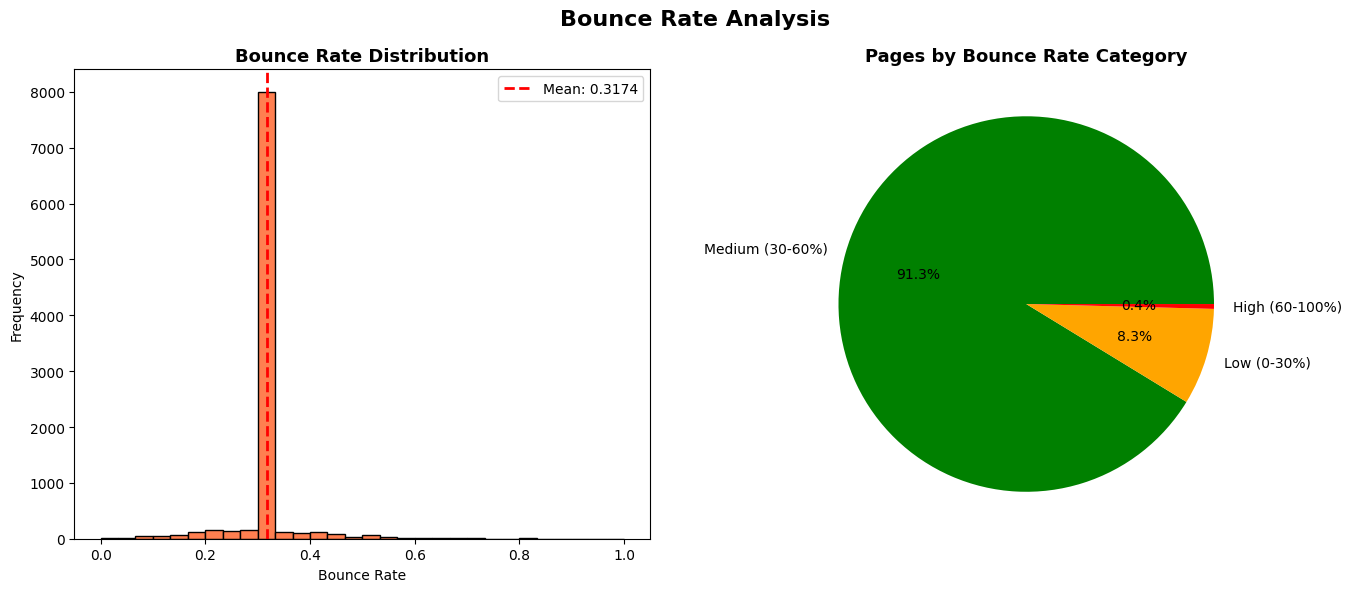

✅ Saved: chart_bounce_rate.png


In [10]:
# ============================================
# CELL 6: BOUNCE RATE ANALYSIS
# ============================================

print("="*50)
print("BOUNCE RATE ANALYSIS")
print("="*50)

print(f"\nAverage Bounce Rate : "
      f"{df2['BounceRate'].mean():.4f}")
print(f"Highest Bounce Rate : "
      f"{df2['BounceRate'].max():.4f}")
print(f"Lowest Bounce Rate  : "
      f"{df2['BounceRate'].min():.4f}")

# Categorize
df2['Bounce_Category'] = pd.cut(
    df2['BounceRate'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=[
        'Low (0-30%)',
        'Medium (30-60%)',
        'High (60-100%)'
    ]
)

print("\nBOUNCE RATE CATEGORIES:")
print(df2['Bounce_Category'].value_counts())

# Charts
fig, axes = plt.subplots(1, 2,
                          figsize=(14, 6))

# Distribution
axes[0].hist(
    df2['BounceRate'].dropna(),
    bins=30,
    color='coral',
    edgecolor='black'
)
axes[0].axvline(
    df2['BounceRate'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean: "
          f"{df2['BounceRate'].mean():.4f}"
)
axes[0].set_title(
    'Bounce Rate Distribution',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bounce Rate')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Pie Chart
bounce_counts = df2[
    'Bounce_Category'].value_counts()
axes[1].pie(
    bounce_counts,
    labels=bounce_counts.index,
    autopct='%1.1f%%',
    colors=['green', 'orange', 'red']
)
axes[1].set_title(
    'Pages by Bounce Rate Category',
    fontsize=13, fontweight='bold')

plt.suptitle(
    'Bounce Rate Analysis',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('charts/chart_bounce_rate.png')
plt.show()
print("✅ Saved: chart_bounce_rate.png")

SEARCH POSITION ANALYSIS
                   Clicks  Impressions  BounceRate   CTR
Position_Category                                       
Top 3                  56         4337        0.32  1.29
Top 10              31273      1089533        0.32  2.87
Top 20              19816      1245297        0.32  1.59
Below 20             5299       680957        0.32  0.78


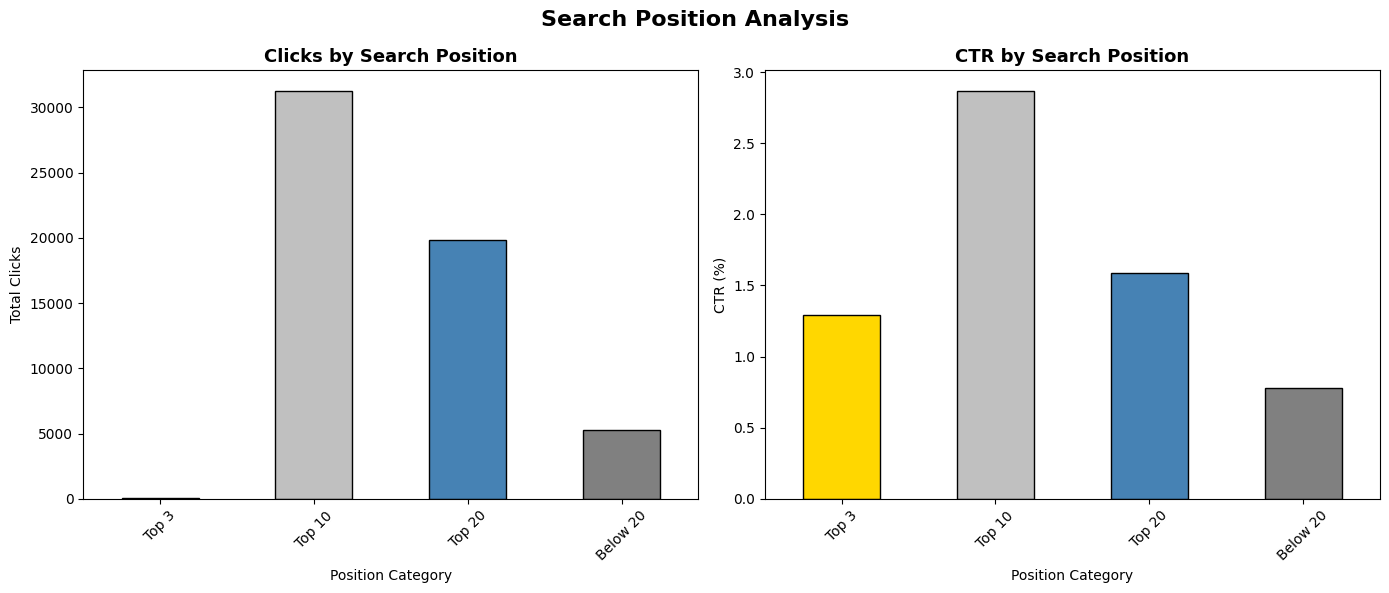

✅ Saved: chart_position.png
✅ Saved: powerbi_position_analysis.csv


In [11]:
# ============================================
# CELL 7: POSITION & CLICKS ANALYSIS
# ============================================

print("="*50)
print("SEARCH POSITION ANALYSIS")
print("="*50)

# Position categories
df2['Position_Category'] = pd.cut(
    df2['Position'],
    bins=[0, 3, 10, 20, 100],
    labels=[
        'Top 3',
        'Top 10',
        'Top 20',
        'Below 20'
    ]
)

pos_analysis = df2.groupby(
    'Position_Category').agg({
    'Clicks'     : 'sum',
    'Impressions': 'sum',
    'BounceRate' : 'mean'
}).round(2)

pos_analysis['CTR'] = (
    pos_analysis['Clicks'] /
    pos_analysis['Impressions'] * 100
).round(2)

print(pos_analysis)

# Charts
fig, axes = plt.subplots(1, 2,
                          figsize=(14, 6))

# Clicks by Position
pos_analysis['Clicks'].plot(
    kind='bar',
    ax=axes[0],
    color=['gold', 'silver',
           'steelblue', 'gray'],
    edgecolor='black'
)
axes[0].set_title(
    'Clicks by Search Position',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Position Category')
axes[0].set_ylabel('Total Clicks')
axes[0].tick_params(
    axis='x', rotation=45)

# CTR by Position
pos_analysis['CTR'].plot(
    kind='bar',
    ax=axes[1],
    color=['gold', 'silver',
           'steelblue', 'gray'],
    edgecolor='black'
)
axes[1].set_title(
    'CTR by Search Position',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Position Category')
axes[1].set_ylabel('CTR (%)')
axes[1].tick_params(
    axis='x', rotation=45)

plt.suptitle(
    'Search Position Analysis',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('charts/chart_position.png')
plt.show()
print("✅ Saved: chart_position.png")

# Save for Power BI
pos_analysis.reset_index().to_csv(
    'powerbi_position_analysis.csv',
    index=False)
print("✅ Saved: powerbi_position_analysis.csv")

CONTENT ANALYSIS
Avg Word Count      : 1686
Avg Title Length    : 120
Avg ViewDepth       : 1.50
Avg Inlinks         : 233
Avg Outlinks        : 155


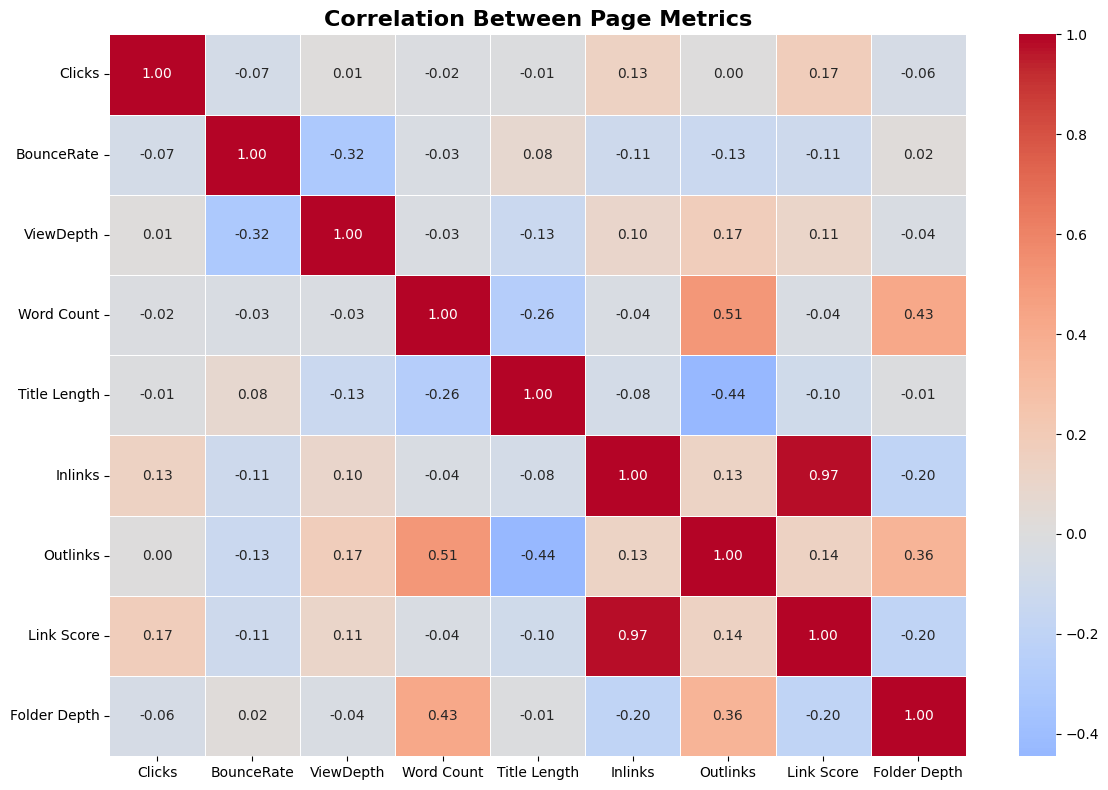

✅ Saved: chart_correlation.png


In [12]:
# ============================================
# CELL 8: CONTENT ANALYSIS
# ============================================

print("="*50)
print("CONTENT ANALYSIS")
print("="*50)

print(f"Avg Word Count      : "
      f"{df2['Word Count'].mean():.0f}")
print(f"Avg Title Length    : "
      f"{df2['Title Length'].mean():.0f}")
print(f"Avg ViewDepth       : "
      f"{df2['ViewDepth'].mean():.2f}")
print(f"Avg Inlinks         : "
      f"{df2['Inlinks'].mean():.0f}")
print(f"Avg Outlinks        : "
      f"{df2['Outlinks'].mean():.0f}")

# Correlation Heatmap
numeric_df = df2[[
    'Clicks',
    'BounceRate',
    'ViewDepth',
    'Word Count',
    'Title Length',
    'Inlinks',
    'Outlinks',
    'Link Score',
    'Folder Depth'
]].copy()

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title(
    'Correlation Between Page Metrics',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('charts/chart_correlation.png')
plt.show()
print("✅ Saved: chart_correlation.png")

In [13]:
# ============================================
# CELL 9: EXPORT ALL FOR POWER BI
# ============================================

print("Exporting files for Power BI...")

# File 1: Cleaned Page Data
df2.to_csv('powerbi_page_main.csv',
            index=False)
print("✅ Exported: powerbi_page_main.csv")

# File 2: Segment Performance
segment_perf.reset_index().to_csv(
    'powerbi_page_performance.csv',
    index=False)
print("✅ Exported: powerbi_page_performance.csv")

# File 3: Position Analysis
pos_analysis.reset_index().to_csv(
    'powerbi_position_analysis.csv',
    index=False)
print("✅ Exported: powerbi_position_analysis.csv")

# File 4: Bounce Categories
bounce_summary = df2.groupby(
    'Bounce_Category').agg({
    'Clicks'     : 'sum',
    'Impressions': 'sum',
    'BounceRate' : 'mean',
    'ViewDepth'  : 'mean'
}).round(2).reset_index()

bounce_summary.to_csv(
    'powerbi_bounce_summary.csv',
    index=False)
print("✅ Exported: powerbi_bounce_summary.csv")

print("\n" + "="*50)
print("ALL EXPORTS COMPLETE!")
print("="*50)
print("\nFiles Ready for Power BI:")
print("  1. powerbi_page_main.csv")
print("  2. powerbi_page_performance.csv")
print("  3. powerbi_position_analysis.csv")
print("  4. powerbi_bounce_summary.csv")

Exporting files for Power BI...
✅ Exported: powerbi_page_main.csv
✅ Exported: powerbi_page_performance.csv
✅ Exported: powerbi_position_analysis.csv
✅ Exported: powerbi_bounce_summary.csv

ALL EXPORTS COMPLETE!

Files Ready for Power BI:
  1. powerbi_page_main.csv
  2. powerbi_page_performance.csv
  3. powerbi_position_analysis.csv
  4. powerbi_bounce_summary.csv


In [14]:
# ============================================
# CELL 10: FINAL SUMMARY REPORT
# ============================================

print("="*60)
print("   PAGE PERFORMANCE - FINAL REPORT")
print("="*60)

print("\n📊 DATASET OVERVIEW:")
print(f"   Total Pages      : {len(df2):,}")
print(f"   Total Segments   : "
      f"{df2['Segments'].nunique()}")

print("\n🖱️ CLICKS SUMMARY:")
print(f"   Total Clicks     : "
      f"{df2['Clicks'].sum():,.0f}")
print(f"   Avg Clicks       : "
      f"{df2['Clicks'].mean():.2f}")
print(f"   Max Clicks       : "
      f"{df2['Clicks'].max():,.0f}")

print("\n👁️ IMPRESSIONS SUMMARY:")
print(f"   Total Impressions: "
      f"{df2['Impressions'].sum():,.0f}")
print(f"   Avg Impressions  : "
      f"{df2['Impressions'].mean():.2f}")

print("\n📈 CTR SUMMARY:")
total_ctr = (df2['Clicks'].sum() /
             df2['Impressions'].sum() * 100)
print(f"   Overall CTR      : "
      f"{total_ctr:.2f}%")

print("\n📉 BOUNCE RATE:")
print(f"   Avg Bounce Rate  : "
      f"{df2['BounceRate'].mean():.4f}")
print(f"   Low Bounce Pages : "
      f"{(df2['BounceRate'] < 0.3).sum()}")
print(f"   High Bounce Pages: "
      f"{(df2['BounceRate'] >= 0.6).sum()}")

print("\n🏆 BEST PERFORMING SEGMENT:")
best = segment_perf['Clicks'].idxmax()
print(f"   {best} with "
      f"{segment_perf.loc[best,'Clicks']:,.0f}"
      f" clicks")

print("\n⚠️ WORST BOUNCE RATE SEGMENT:")
worst = segment_perf['BounceRate'].idxmax()
print(f"   {worst} with "
      f"{segment_perf.loc[worst,'BounceRate']:.4f}"
      f" bounce rate")

print("\n✅ CHARTS CREATED:")
charts = [
    "chart_page_performance.png",
    "chart_bounce_rate.png",
    "chart_position.png",
    "chart_correlation.png"
]
for i, c in enumerate(charts, 1):
    print(f"   {i}. {c}")

print("\n✅ POWER BI FILES:")
files = [
    "powerbi_page_main.csv",
    "powerbi_page_performance.csv",
    "powerbi_position_analysis.csv",
    "powerbi_bounce_summary.csv"
]
for i, f in enumerate(files, 1):
    print(f"   {i}. {f}")

print("\n" + "="*60)
print("   PROJECT COMPLETE! ✅")
print("="*60)

   PAGE PERFORMANCE - FINAL REPORT

📊 DATASET OVERVIEW:
   Total Pages      : 9,439
   Total Segments   : 4

🖱️ CLICKS SUMMARY:
   Total Clicks     : 56,444
   Avg Clicks       : 5.98
   Max Clicks       : 1,939

👁️ IMPRESSIONS SUMMARY:
   Total Impressions: 3,020,134
   Avg Impressions  : 319.96

📈 CTR SUMMARY:
   Overall CTR      : 1.87%

📉 BOUNCE RATE:
   Avg Bounce Rate  : 0.3174
   Low Bounce Pages : 768
   High Bounce Pages: 52

🏆 BEST PERFORMING SEGMENT:
   product with 26,220 clicks

⚠️ WORST BOUNCE RATE SEGMENT:
   product with 0.3249 bounce rate

✅ CHARTS CREATED:
   1. chart_page_performance.png
   2. chart_bounce_rate.png
   3. chart_position.png
   4. chart_correlation.png

✅ POWER BI FILES:
   1. powerbi_page_main.csv
   2. powerbi_page_performance.csv
   3. powerbi_position_analysis.csv
   4. powerbi_bounce_summary.csv

   PROJECT COMPLETE! ✅
